In [54]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [55]:
df = pd.read_csv('../data/processed/rq1_features.csv')

In [56]:
features = [
    'price_lag_1h', 'price_lag_24h', 'price_lag_168h',
    'hour', 'day_of_week', 'month', 'is_weekend',
    'temperature_2m', 'wind_speed_10m', 'cloud_cover', 'shortwave_radiation',
    'P', 'P_lag_1h', 'P_lag_24h'
]

In [57]:
X = df[features]
y = df['Price (EUR/MWhe)']

In [58]:
train_end = int(len(df) * 0.70)
val_end = int(len(df) * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

In [59]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [60]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} EUR/MWh")
print(f"RMSE: {rmse:.2f} EUR/MWh")
print(f"R²:   {r2*100:.1f}%")

MAE:  10.53 EUR/MWh
RMSE: 18.54 EUR/MWh
R²:   85.6%


In [61]:
y_val_pred = model.predict(X_val)
print(mean_absolute_error(y_val, y_val_pred))
print(r2_score(y_val, y_val_pred))

7.700449152491452
0.8558549433512397


In [62]:
y_test_pred = model.predict(X_test)
print(mean_absolute_error(y_test, y_test_pred))
print(r2_score(y_test, y_test_pred))

10.52725223056631
0.8556986144866232


In [63]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

importance = importance.sort_values(
    by='importance',
    ascending=False
)

print(importance)

                feature  importance
0          price_lag_1h    0.396401
1         price_lag_24h    0.265541
8        wind_speed_10m    0.074891
2        price_lag_168h    0.070416
4           day_of_week    0.064959
11                    P    0.025890
3                  hour    0.023898
10  shortwave_radiation    0.015488
6            is_weekend    0.015326
13            P_lag_24h    0.014606
7        temperature_2m    0.014488
12             P_lag_1h    0.009083
9           cloud_cover    0.006072
5                 month    0.002941


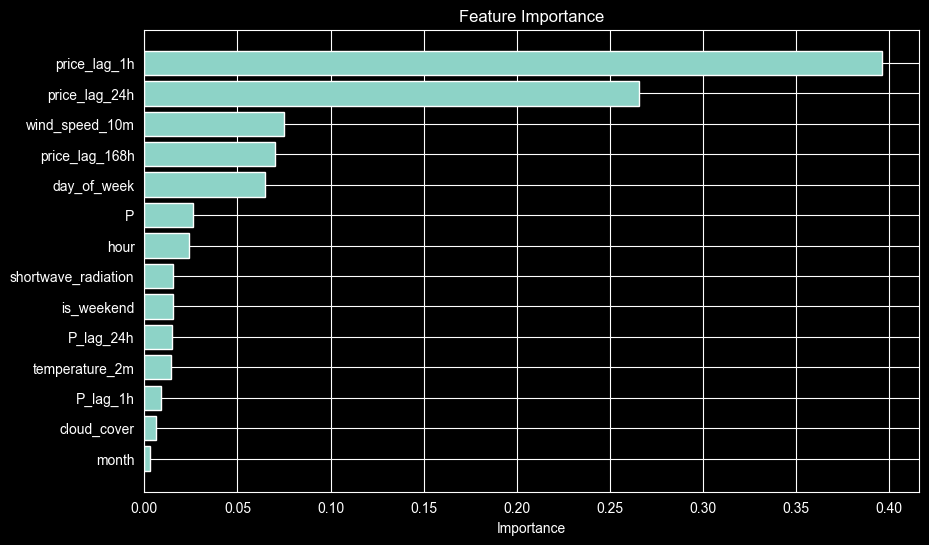

In [64]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['feature'],
    importance['importance']
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance")

plt.show()

In [65]:
y_train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"TRAIN: MAE: {train_mae:.2f}, RMSE: {train_rmse:.2f}, R²: {train_r2*100:.1f}%")
print(f"TEST: MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2*100:.1f}%")

TRAIN: MAE: 3.70, RMSE: 5.05, R²: 98.3%
TEST: MAE: 10.53, RMSE: 18.54, R²: 85.6%
